In [ ]:
pip install ipykernel opencv-python numpy matplotlib scikit-learn

In [19]:
import os

# Carpeta donde están las imágenes
carpeta = "cuadrados"

# Obtener lista de archivos .jpg
archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(".jpg")]

# Ordenarlos (opcional pero recomendado)
archivos.sort()

# Renombrar
for i, nombre_original in enumerate(archivos):
    ruta_original = os.path.join(carpeta, nombre_original)
    nuevo_nombre = f"imagen_{i}.jpg"
    ruta_nueva = os.path.join(carpeta, nuevo_nombre)
    
    os.rename(ruta_original, ruta_nueva)

print("Renombrado completado.")

Renombrado completado.


In [1]:
import cv2
import os
import time

def capturar_en_carpeta(nombre_carpeta="diamantes", num_fotos=200, intervalo_seg=0.1):
    
    # Crear carpeta si no existe
    os.makedirs(nombre_carpeta, exist_ok=True)

    # Abrir webcam
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara")
        return

    print("📷 Capturando imágenes...")

    contador = 0

    while contador < num_fotos:
        ret, frame = cap.read()

        if not ret:
            print("❌ Error al capturar imagen")
            break

        # Mostrar en ventana
        cv2.imshow("Captura", frame)

        # Guardar imagen
        nombre_archivo = os.path.join(nombre_carpeta, f"imagen_{contador}.jpg")
        cv2.imwrite(nombre_archivo, frame)

        contador += 1
        print(f"Guardada {nombre_archivo}")

        # Esperar intervalo
        time.sleep(intervalo_seg)

        # Permite cerrar con tecla q
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"✅ Se guardaron {contador} imágenes en '{nombre_carpeta}'")

In [2]:
capturar_en_carpeta("diamantes", 200, 0.1)

📷 Capturando imágenes...


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/plugins"
QFont::fromString: Invalid description 'Noto Sans,13,-1,5,400,0,0,0,0,0,0,0,0,0,0,1'
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.


Guardada diamantes/imagen_0.jpg
Guardada diamantes/imagen_1.jpg
Guardada diamantes/imagen_2.jpg
Guardada diamantes/imagen_3.jpg
Guardada diamantes/imagen_4.jpg
Guardada diamantes/imagen_5.jpg
Guardada diamantes/imagen_6.jpg
Guardada diamantes/imagen_7.jpg
Guardada diamantes/imagen_8.jpg
Guardada diamantes/imagen_9.jpg
Guardada diamantes/imagen_10.jpg
Guardada diamantes/imagen_11.jpg
Guardada diamantes/imagen_12.jpg
Guardada diamantes/imagen_13.jpg
Guardada diamantes/imagen_14.jpg
Guardada diamantes/imagen_15.jpg
Guardada diamantes/imagen_16.jpg
Guardada diamantes/imagen_17.jpg
Guardada diamantes/imagen_18.jpg
Guardada diamantes/imagen_19.jpg
Guardada diamantes/imagen_20.jpg
Guardada diamantes/imagen_21.jpg
Guardada diamantes/imagen_22.jpg
Guardada diamantes/imagen_23.jpg
Guardada diamantes/imagen_24.jpg
Guardada diamantes/imagen_25.jpg
Guardada diamantes/imagen_26.jpg
Guardada diamantes/imagen_27.jpg
Guardada diamantes/imagen_28.jpg
Guardada diamantes/imagen_29.jpg
Guardada diamantes/i

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def procesar_imagen(ruta_imagen):
    """
    Carga una imagen y realiza:
    - Redimensionamiento a 50x50
    - Conversión a escala de grises
    - Binarización (0 fondo blanco, 1 trazo negro)
    """
    
    # Cargar imagen
    img = cv2.imread(ruta_imagen)
    
    # Redimensionar
    img = cv2.resize(img, (50, 50))
    
    # Convertir a escala de grises
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Binarización
    _, binaria = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Convertir 255 → 1
    binaria = binaria // 255
    
    return binaria

In [16]:
# Definir carpetas y etiquetas
carpetas = {
    "triangulos": 0,
    "cuadrados": 1,
    #"diamantes": 2
}

X = []
y = []

for carpeta, etiqueta in carpetas.items():
    
    for archivo in os.listdir(carpeta):
        
        ruta = os.path.join(carpeta, archivo)
        
        # Procesar imagen
        img_procesada = procesar_imagen(ruta)
        
        # Vectorizar (50x50 → 2500)
        vector = img_procesada.flatten()
        
        X.append(vector)
        y.append(etiqueta)

# Convertir a numpy
X = np.array(X)
y = np.array(y)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (161, 2500)
Forma de y: (161,)


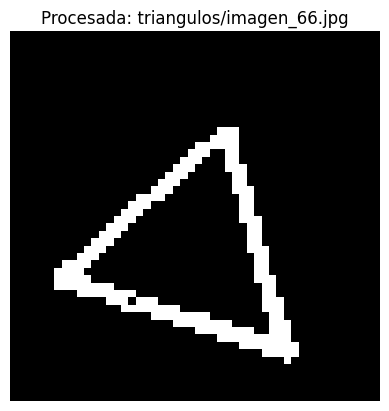

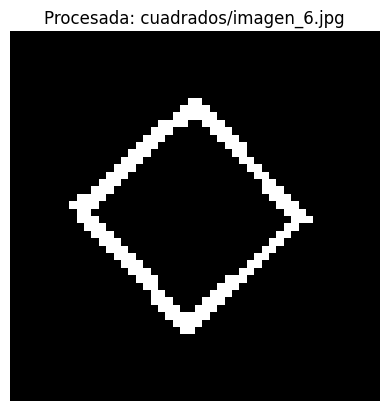

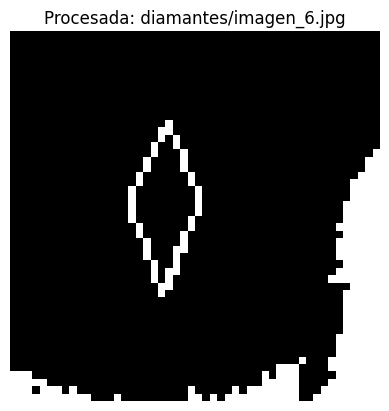

In [ ]:
import matplotlib.pyplot as plt

def mostrar_imagen_procesada(ruta_imagen):
    
    img_procesada = procesar_imagen(ruta_imagen)
    
    plt.imshow(img_procesada, cmap='gray')
    plt.title(f"Procesada: {ruta_imagen}")
    plt.axis("off")
    plt.show()

# 👉 Escribe aquí la imagen que quieras visualizar
nombre = "triangulos/imagen_66.jpg"
nombre1 = "cuadrados/imagen_6.jpg"
#nombre2 = "diamantes/imagen_6.jpg"



mostrar_imagen_procesada(nombre)
mostrar_imagen_procesada(nombre1)
#mostrar_imagen_procesada(nombre2)


##¿Qué representa cada fila de la matriz X? ¿Qué representa cada columna?

Cada fila de la matriz X representa una imagen completa ya vectorizada.
Es decir, una forma geométrica (triángulo o cuadrado) convertida en un vector de 2500 dimensiones.

Cada columna representa un píxel específico dentro de la imagen.
Como la imagen fue redimensionada a 50×50, cada una tiene 2500 píxeles, y cada columna corresponde a uno de esos píxeles (con valor 0 o 1 después de la binarización).

##Si dos imágenes del mismo objeto son visualmente similares, pero tienen pequeñas variaciones en el trazo, ¿qué espera que ocurra con sus representaciones vectoriales?
##¿Estarán cerca o lejos en el espacio de 2500 dimensiones?

##¿Puede visualizar mentalmente un espacio de 2500 dimensiones? Si no es posible,
##¿cómo podríamos obtener una representación visual de la estructura de nuestros datos?

#Etapa 2

1. Estandarizar X

In [17]:
from sklearn.preprocessing import StandardScaler
#Estandarizar X
scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

print("Forma X escalado:", X_escalado.shape)

Forma X escalado: (161, 2500)


2. Aplicar PCA con 2 componentes

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_proyectada = pca.fit_transform(X_escalado)

print("Forma X_proyectada:", X_proyectada.shape)

Forma X_proyectada: (161, 2)


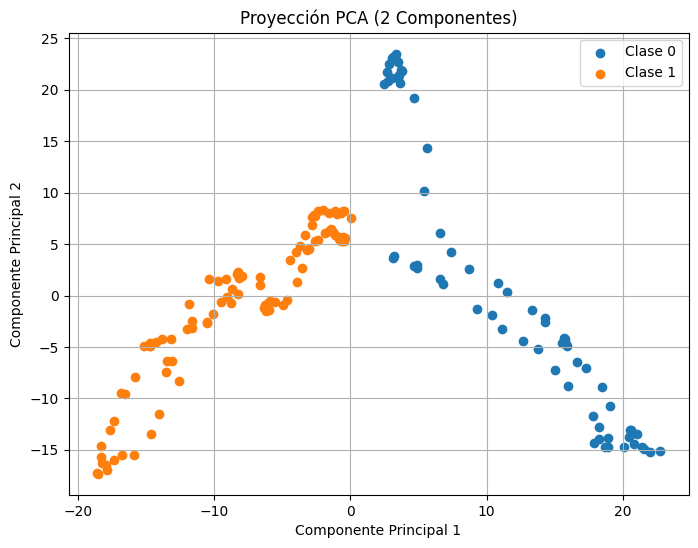

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Para cada clase distinta
for clase in np.unique(y):
    
    plt.scatter(
        X_proyectada[y == clase, 0],
        X_proyectada[y == clase, 1],
        label=f"Clase {clase}"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA (2 Componentes)")
plt.legend()
plt.grid()
plt.show()

In [20]:
print(pca.explained_variance_ratio_)

[0.09282494 0.07691384]


#Etapa 3

##Entrenar regresión logistica

In [25]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
modelo = LogisticRegression()

# Entrenar usando los datos proyectados (2D)
modelo.fit(X_proyectada, y)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


##Generar malla de puntos

In [26]:
import numpy as np

# Definir límites del gráfico
x_min, x_max = X_proyectada[:, 0].min() - 1, X_proyectada[:, 0].max() + 1
y_min, y_max = X_proyectada[:, 1].min() - 1, X_proyectada[:, 1].max() + 1

# Crear malla
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Convertir malla a formato (n_puntos, 2)
malla = np.c_[xx.ravel(), yy.ravel()]

##Predecir clase en cada punto de la malla

In [27]:
Z = modelo.predict(malla)

# Volver a forma de malla
Z = Z.reshape(xx.shape)

##Dibujar frontera de decisión + puntos originales

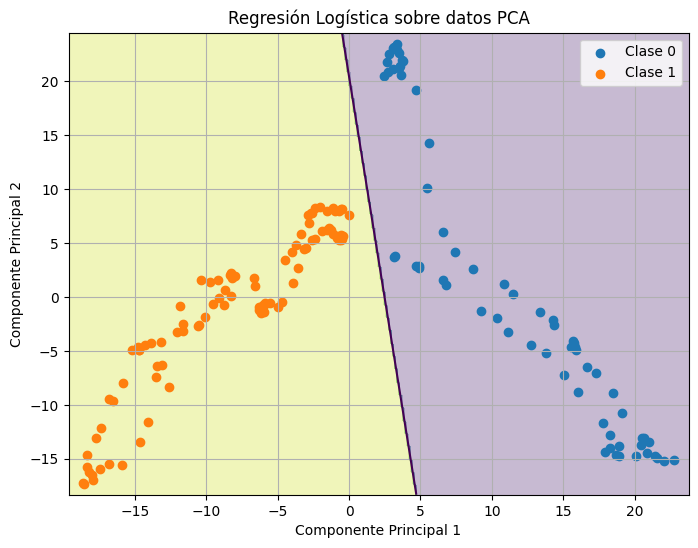

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Dibujar regiones de decisión
plt.contourf(xx, yy, Z, alpha=0.3)

# Dibujar frontera donde probabilidad = 0.5
probs = modelo.predict_proba(malla)[:, 1]
probs = probs.reshape(xx.shape)

plt.contour(xx, yy, probs, levels=[0.5])

# Dibujar datos originales
for clase in np.unique(y):
    plt.scatter(
        X_proyectada[y == clase, 0],
        X_proyectada[y == clase, 1],
        label=f"Clase {clase}"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Regresión Logística sobre datos PCA")
plt.legend()
plt.grid()
plt.show()